In [1]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

from utils.solver import Solver
from utils.iso_reactor_utils import generate_config, generate_config_seq
from utils.vapour_reactor_utils import plot_reactor_solutions

from coupled.vapour_reactor import VapourReactor
from coupled.iso_reactor import Reactor

Mesh warning: N_Z changed from 50 to 46
Mesh warning: Neutronics N_Z changed from 50 to 30


In [3]:
with open("./data/reactor_data.json", "r") as f:
    data = json.load(f)
    data["Reactor"]["power"]["thermal"] = 15e6
    data["HeatPipe"]["material"]["h_cond"] = 225

In [ ]:
# Coarse mesh
Ns_coarse = [15, 15, 30]
cfg_coarse = generate_config(data, *Ns_coarse)

vap_reactor_coarse = VapourReactor(cfg_coarse)
vap_reactor_coarse.set_variable_k(False)
vap_reactor_coarse.set_variable_neutron_data(False)

# Fine mesh
Ns = [15, 15, 60]
cfg = generate_config(data, *Ns)

vap_reactor = VapourReactor(cfg)
vap_reactor.set_variable_k(True)
vap_reactor.set_variable_neutron_data(True)

# Solve iteratively
solver = Solver([vap_reactor_coarse, vap_reactor], iterate = True)
solver.fsolve()

Mesh warning: N_Z changed from 60 to 69
Mesh warning: Fuel pin N_Z changed from 27 to 45
Mesh warning: Neutronics N_Z changed from 27 to 45
Mesh warning: N_Z changed from 30 to 23
Mesh warning: Fuel pin N_Z changed from 13 to 15
Mesh warning: Neutronics N_Z changed from 13 to 15
Solving Heat pipe initial values
fsolve message: The solution converged.
final residual L2 norm: 9.412e-07
Running iteration 1 ...
fsolve message: The solution converged.
final residual L2 norm: 4.257e-04
Running iteration 2 ...
fsolve message: The solution converged.
final residual L2 norm: 2.775e-04


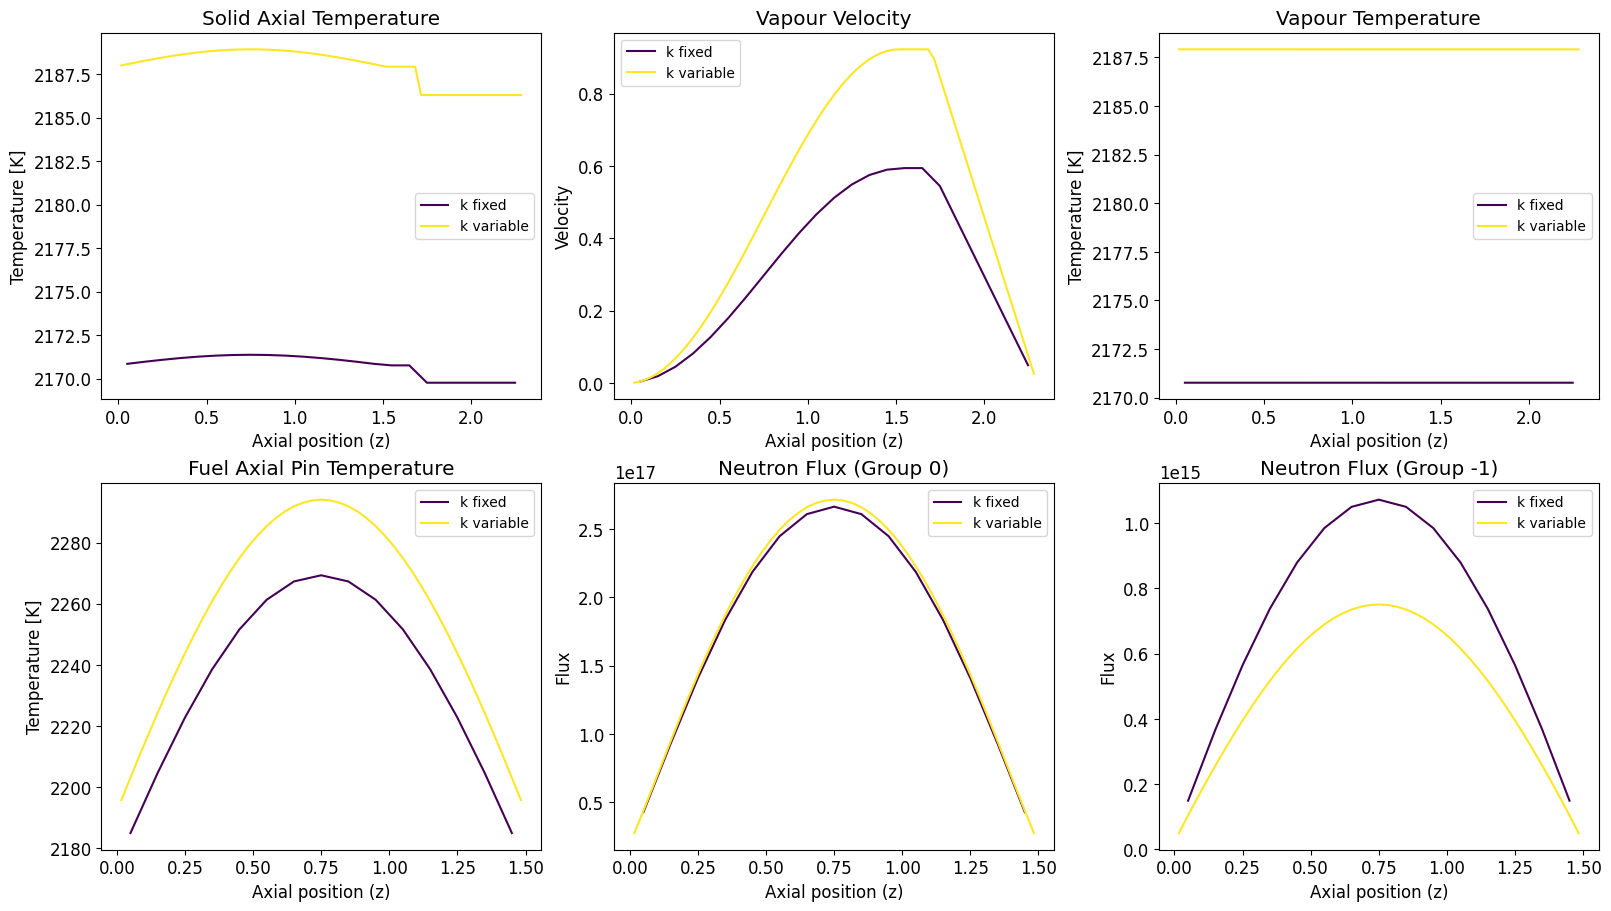

In [7]:
plot_reactor_solutions(solver)